<!-- colab-badge-top -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/01c_sampler_diagnostics.ipynb)

# Extension lab: can you trust the sampler?

**FQCP 2026 · Convergence, geometry, and predictive diagnostics**

A corner plot is not a convergence test. This short lab separates three
questions:

1. **Mixing:** did independent chains explore the same distribution?
2. **Geometry:** did the algorithm encounter regions it could not traverse
   faithfully?
3. **Model adequacy:** can the fitted model reproduce or predict data?

The first two diagnose the computation. The third diagnoses the model. A
sampler can pass while the model is wrong, and a good model can still be fit by
a failed sampler.

## 1. Four chains: one healthy example, one stuck example

The draws below are synthetic Markov chains, not a fitted scientific model.
Their autocorrelation makes them useful for seeing what the diagnostics detect.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rankdata

warnings.filterwarnings("ignore", message="IProgress not found.*")
from numpyro.diagnostics import effective_sample_size, split_gelman_rubin

rng = np.random.default_rng(20260903)
plt.style.use("seaborn-v0_8-whitegrid")


def ar1_chains(means, draws=1600, correlation=0.85):
    """Simulate stationary autocorrelated chains with chosen means."""
    chains = np.empty((len(means), draws))
    innovation_scale = np.sqrt(1 - correlation**2)
    for chain_index, mean in enumerate(means):
        chains[chain_index, 0] = mean + rng.normal()
        for draw in range(1, draws):
            chains[chain_index, draw] = (
                mean
                + correlation * (chains[chain_index, draw - 1] - mean)
                + innovation_scale * rng.normal()
            )
    return chains


good_chains = ar1_chains([0.0, 0.0, 0.0, 0.0])
stuck_chains = ar1_chains([0.0, 0.0, 0.0, 1.5])

**Predict before plotting:** which failure should be easier to see in a trace
plot: strong autocorrelation within every chain, or one chain sampling a
different location?

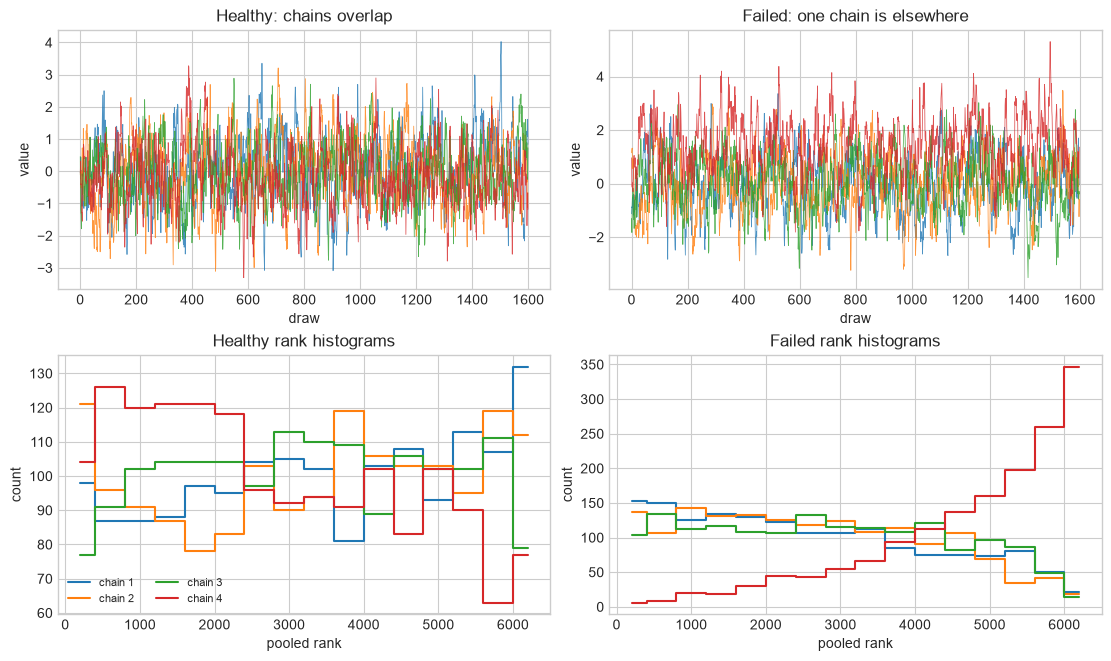

healthy: R-hat=1.005, bulk ESS=621, tail ESS=1045, MCSE(mean)=0.039
stuck  : R-hat=1.186, bulk ESS=7, tail ESS=23, MCSE(mean)=0.443


In [2]:
def rank_normalise(chains):
    ranks = rankdata(chains.ravel(), method="average")
    transformed = norm.ppf((ranks - 3 / 8) / (ranks.size + 1 / 4))
    return transformed.reshape(chains.shape)


def rank_normalised_rhat(chains):
    """Maximum of rank-normalised split and folded-split R-hat."""
    rank_rhat = float(split_gelman_rubin(rank_normalise(chains)))
    folded = np.abs(chains - np.median(chains))
    folded_rhat = float(split_gelman_rubin(rank_normalise(folded)))
    return max(rank_rhat, folded_rhat)


def bulk_and_tail_ess(chains):
    bulk = float(effective_sample_size(rank_normalise(chains)))
    lower, upper = np.quantile(chains, [0.05, 0.95])
    lower_indicator = (chains <= lower).astype(float)
    upper_indicator = (chains >= upper).astype(float)
    tail = min(
        float(effective_sample_size(lower_indicator)),
        float(effective_sample_size(upper_indicator)),
    )
    return bulk, tail


def rank_histogram(ax, chains, title):
    ranks = rankdata(chains.ravel()).reshape(chains.shape)
    bins = np.linspace(0.5, ranks.size + 0.5, 17)
    for chain_index, chain_ranks in enumerate(ranks):
        counts, edges = np.histogram(chain_ranks, bins=bins)
        centres = 0.5 * (edges[:-1] + edges[1:])
        ax.step(centres, counts, where="mid", label=f"chain {chain_index + 1}")
    ax.set(xlabel="pooled rank", ylabel="count", title=title)


fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), constrained_layout=True)
for chain_index in range(good_chains.shape[0]):
    axes[0, 0].plot(good_chains[chain_index], lw=0.55, alpha=0.8)
    axes[0, 1].plot(stuck_chains[chain_index], lw=0.55, alpha=0.8)
axes[0, 0].set(xlabel="draw", ylabel="value", title="Healthy: chains overlap")
axes[0, 1].set(xlabel="draw", ylabel="value", title="Failed: one chain is elsewhere")
rank_histogram(axes[1, 0], good_chains, "Healthy rank histograms")
rank_histogram(axes[1, 1], stuck_chains, "Failed rank histograms")
axes[1, 0].legend(fontsize=8, ncol=2)
plt.show()

for name, chains in [("healthy", good_chains), ("stuck", stuck_chains)]:
    rhat = rank_normalised_rhat(chains)
    bulk_ess, tail_ess = bulk_and_tail_ess(chains)
    mcse_mean = np.std(chains, ddof=1) / np.sqrt(bulk_ess)
    print(
        f"{name:7s}: R-hat={rhat:.3f}, bulk ESS={bulk_ess:.0f}, "
        f"tail ESS={tail_ess:.0f}, MCSE(mean)={mcse_mean:.3f}"
    )

## 2. What the chain summaries mean

| Check | Question | How to read it |
| --- | --- | --- |
| rank-normalised split $\widehat R$ | do between-chain and within-chain variation agree? | values near 1 are necessary; use $\widehat R<1.01$ as a strong default, not a proof |
| bulk ESS | how many independent draws inform locations such as the mean or median? | report ESS, not just stored draws |
| tail ESS | are intervals and tail probabilities estimated precisely? | especially important for credible bounds and rare-event probabilities |
| MCSE | how much numerical error remains in a reported posterior summary? | it should be small relative to the precision you quote |
| trace and rank plots | did chains mix locally and occupy the same ranks? | look for sticking, drift, separated chains, or uneven ranks |

Modern $\widehat R$ uses rank normalisation, chain splitting, and folding so it
can detect more than a difference in means. It still cannot prove global
convergence: four chains can all become trapped in the same mode. Start chains
from dispersed locations and inspect scientifically important derived
quantities, not only the sampled coordinates.

## 3. NUTS and HMC: inspect the trajectory geometry

Good $\widehat R$ and ESS do not excuse a transition-level warning.

| Warning | What it suggests | First response |
| --- | --- | --- |
| divergent transitions | the numerical trajectory could not follow a region of posterior curvature | locate divergences in parameter space; reparameterise, rescale, or reconsider the model |
| maximum tree depth | NUTS repeatedly needed a longer trajectory than allowed | inspect scaling and geometry before merely raising the limit |
| low E-BFMI | momentum resampling is exploring the energy distribution poorly | inspect energy plots and consider reparameterisation |
| very low acceptance | proposals or trajectories are too aggressive | retune step size or proposal scale |
| very high acceptance | possibly tiny steps and inefficient exploration | check ESS per second, not acceptance alone |

Raising `target_accept` can remove some divergences by reducing the step size,
but persistent divergences usually demand a better parameterisation. The goal
is not to silence the warning; it is to make the posterior geometry tractable.

## 4. Other samplers need different checks

| Method | Minimum useful checks |
| --- | --- |
| random-walk or ensemble MCMC | multiple runs, $\widehat R$, bulk/tail ESS, MCSE, autocorrelation, trace/rank plots, mode coverage |
| HMC / NUTS | all MCMC checks plus divergences, tree depth, E-BFMI, acceptance, and step size |
| nested sampling | repeated-run stability of $\log\mathcal Z$ and posterior summaries, live-point adequacy, termination error, posterior weights, and mode recovery |
| variational inference | several initialisations, ELBO stability, comparison with a trusted sampler on representative cases, predictive checks, and coverage tests |

An error bar reported by nested sampling or a stable ELBO from VI is not a
universal convergence certificate. Each algorithm's approximation can fail in
a different way.

## 5. PSIS-LOO answers a different question

Leave-one-out cross-validation asks how well the fitted model predicts each
observation when that observation is left out:

$$
\operatorname{elpd}_{\rm LOO}
=\sum_i \log\int p(y_i\mid\theta)\,p(\theta\mid y_{-i})\,d\theta.
$$

Pareto-smoothed importance sampling (PSIS) approximates those leave-one-out
fits by reweighting draws from the full posterior. The Pareto shape diagnostic
$\widehat k$ checks whether those importance weights have a manageable tail.

- PSIS-LOO requires a **pointwise log-likelihood**, one contribution per
  observation and posterior draw.
- A problematic $\widehat k$ identifies an influential observation or an
  unreliable importance-sampling approximation. Use the software's
  sample-size-dependent threshold; then consider moment matching, an explicit
  leave-one-out refit, or $K$-fold cross-validation.
- PSIS-LOO compares predictive performance. It does **not** establish that the
  chains converged, and it should be computed only after sampler diagnostics
  pass.

Posterior predictive checks ask whether a model can reproduce relevant data
features. PSIS-LOO asks how well it predicts held-out observations. Both come
after computational checks.

## 6. Your turn: diagnose three reports

For each report, write one of: `sampler failure`, `predictive warning`, or
`no obvious failure`, followed by the next action you would take.

In [3]:
reports = {
    "A": {"rhat": 1.003, "bulk_ess": 1800, "divergences": 9, "max_k": 0.42},
    "B": {"rhat": 1.040, "bulk_ess": 95, "divergences": 0, "max_k": 0.38},
    "C": {"rhat": 1.002, "bulk_ess": 1500, "divergences": 0, "max_k": 0.91},
}

for label, report in reports.items():
    print(label, report)

# Add your verdicts here.
verdicts = {}

A {'rhat': 1.003, 'bulk_ess': 1800, 'divergences': 9, 'max_k': 0.42}
B {'rhat': 1.04, 'bulk_ess': 95, 'divergences': 0, 'max_k': 0.38}
C {'rhat': 1.002, 'bulk_ess': 1500, 'divergences': 0, 'max_k': 0.91}


<details><summary>Hint</summary>

Check computation before prediction. Any divergence needs investigation;
$\widehat R=1.04$ and low ESS indicate poor mixing; a high Pareto
$\widehat k$ does not by itself say that MCMC failed.

</details>

<details><summary>Solution check</summary>

- **A — sampler failure:** locate the divergent draws and repair or retune the
  geometry before using the posterior.
- **B — sampler failure:** run longer only after checking chains, modes,
  scaling, and parameterisation; more draws from a stuck chain do not help.
- **C — predictive warning:** the chains have no obvious listed failure, but
  PSIS-LOO is unreliable for at least one observation. Inspect it and use
  moment matching, an explicit refit, or $K$-fold validation.

</details>

## A practical order of operations

1. Run multiple dispersed chains or independent runs.
2. Check $\widehat R$, bulk/tail ESS, MCSE, trace plots, and rank plots.
3. Check sampler-specific warnings such as divergences or evidence stability.
4. Only then interpret posterior summaries.
5. Check the model with prior/posterior predictions and calibration.
6. Use PSIS-LOO or another held-out method when predictive comparison is the
   scientific question.

## Read or try next

- [Vehtari et al., *Rank-normalization, folding, and localization*](https://doi.org/10.1214/20-BA1221)
  develops the modern $\widehat R$, bulk/tail ESS, and rank-plot recommendations.
- The [Stan diagnostic guide](https://mc-stan.org/docs/2_39/cmdstan-guide/diagnose_utility.html)
  explains divergences, tree depth, E-BFMI, ESS, and $\widehat R$ in practice.
- [Vehtari et al., *Pareto Smoothed Importance Sampling*](https://www.jmlr.org/papers/v25/19-556.html)
  defines PSIS and the Pareto $\widehat k$ diagnostic.
- [Gelman et al., *Bayesian Workflow*](https://arxiv.org/abs/2011.01808)
  places computational checks, predictive checks, and model revision in one
  analysis workflow.

<!-- colab-badge-next -->
Next: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/01d_hubble_prior_sensitivity.ipynb)